#### Importing necessary libraries


In [278]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


##### CSV to DataFrame and DataFrame Copy

In [ ]:
df = pd.read_csv('../data/coffe_quality.csv')## File Path -> ../data/coffe_quality.csv

In [280]:
df_clean = df.copy()

##### Review of Types in The DataFrame

In [281]:
df_clean.dtypes

Unnamed: 0                 int64
ID                         int64
Country of Origin            str
Farm Name                    str
Lot Number                   str
Mill                         str
ICO Number                   str
Company                      str
Altitude                     str
Region                       str
Producer                     str
Number of Bags             int64
Bag Weight                   str
In-Country Partner           str
Harvest Year                 str
Grading Date                 str
Owner                        str
Variety                      str
Status                       str
Processing Method            str
Aroma                    float64
Flavor                   float64
Aftertaste               float64
Acidity                  float64
Body                     float64
Balance                  float64
Uniformity               float64
Clean Cup                float64
Sweetness                float64
Overall                  float64
Defects   

##### Removal of Unnecessary Columns

In [282]:
columns_to_drop = [
    "Unnamed: 0", "ID", "Farm Name", "Lot Number", "Mill",
    "ICO Number", "Company", "Producer", "In-Country Partner",
    "Owner", "Grading Date", "Expiration", "Certification Body",
    "Certification Address", "Certification Contact","Region",
    "Altitude","Status"
]
df_clean = df_clean.drop(columns= columns_to_drop)

##### Data Type Conversion

In [283]:
df_clean["Bag Weight"] = df_clean["Bag Weight"].str.replace(" kg", "").astype(float)

In [284]:
df_clean["Harvest Year"] = df_clean["Harvest Year"].str.split("/").str[0]
df_clean["Harvest Year"] = pd.to_numeric(df_clean["Harvest Year"], errors="coerce")

In [285]:
df_clean["Harvest Year"]

0      2021
1      2021
2      2021
3      2022
4      2022
       ... 
202    2022
203    2022
204    2021
205    2023
206    2021
Name: Harvest Year, Length: 207, dtype: int64

In [286]:

df_clean["Country of Origin"].value_counts()#->"Country of Origin","Variety","Processing Method","Color"

Country of Origin
Taiwan                          61
Guatemala                       21
Colombia                        19
Honduras                        13
Thailand                        12
Ethiopia                        11
Brazil                          10
Costa Rica                       8
Nicaragua                        7
El Salvador                      7
Tanzania, United Republic Of     6
United States (Hawaii)           5
Peru                             4
Vietnam                          4
Mexico                           4
Laos                             3
Uganda                           3
Indonesia                        3
Kenya                            2
Panama                           2
Madagascar                       1
Myanmar                          1
Name: count, dtype: int64

In [287]:
threshold = 10
columns = ["Country of Origin",
        "Variety",
        "Processing Method",
        "Color"]



In [288]:
for col in columns:
    counts = df_clean[col].value_counts()
    df_clean[col] = df_clean[col].apply(
        lambda x: x if counts.get(x,0) >= threshold else "Other"
    )

In [289]:
df_clean["Color"].value_counts()#->"Country of Origin","Variety","Processing Method","Color"

Color
green           101
greenish         36
Other            27
bluish-green     21
blue-green       12
yellow-green     10
Name: count, dtype: int64

##### Applying Dummy Encoding for Correlation Analysis 

In [290]:
df_clean_2 = pd.get_dummies( ##Creating a Backup DataFrame Before Dummy Encoding
    df_clean, columns=[
        "Country of Origin",
        "Variety",
        "Processing Method",
        "Color"
    ],
    drop_first= True
)

In [291]:
corr = df_clean_2.corr(numeric_only=True)

##### Matrix Correlation


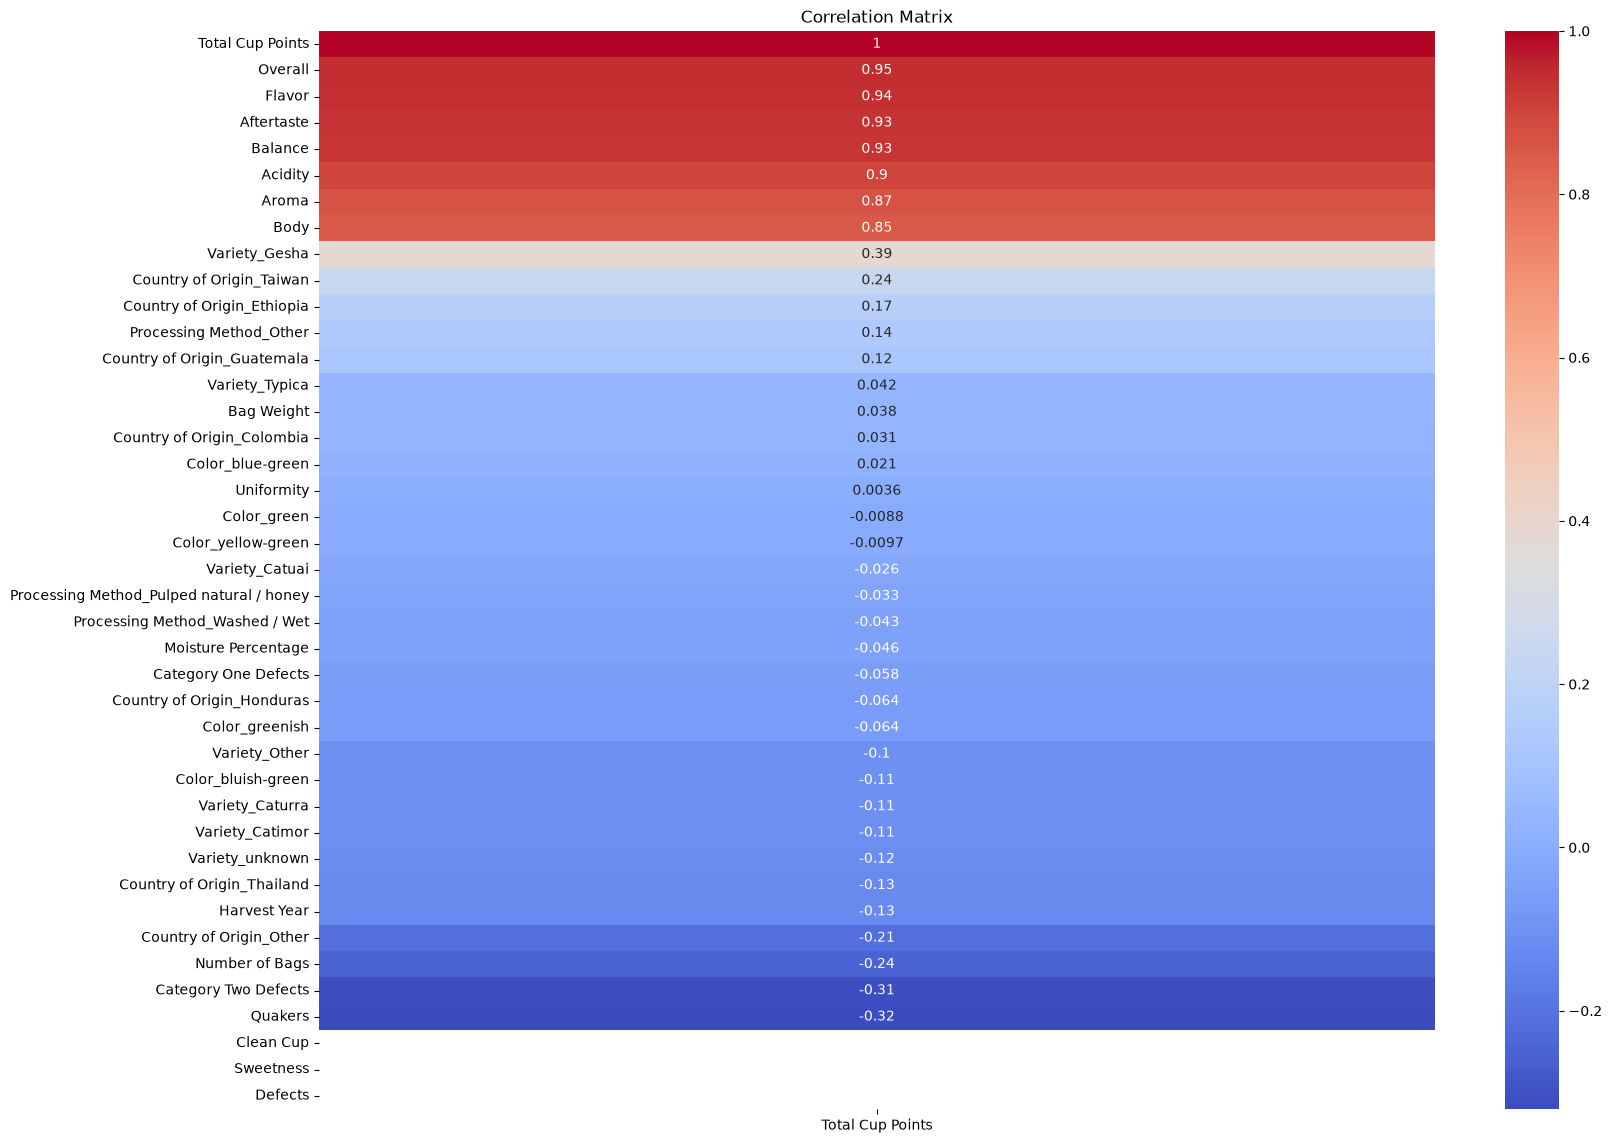

In [292]:
plt.figure(figsize=(18,14))
sns.heatmap(
    corr[["Total Cup Points"]].sort_values(
            by = "Total Cup Points",
            ascending=False
    ),
    annot=True,
    cmap="coolwarm"
    )
plt.title("Correlation Matrix")
plt.show()

In [293]:
df_clean = df_clean.drop(columns=["Sweetness", "Defects", "Clean Cup"])## Without any correlation

In [294]:
##Very Little Correlation
df_clean = df_clean.drop(columns=["Uniformity", "Bag Weight", "Moisture Percentage", "Category One Defects", "Country of Origin","Variety","Processing Method","Color", "Harvest Year"])

In [295]:
corr = df_clean.corr(numeric_only=True)

#### Better Correlations

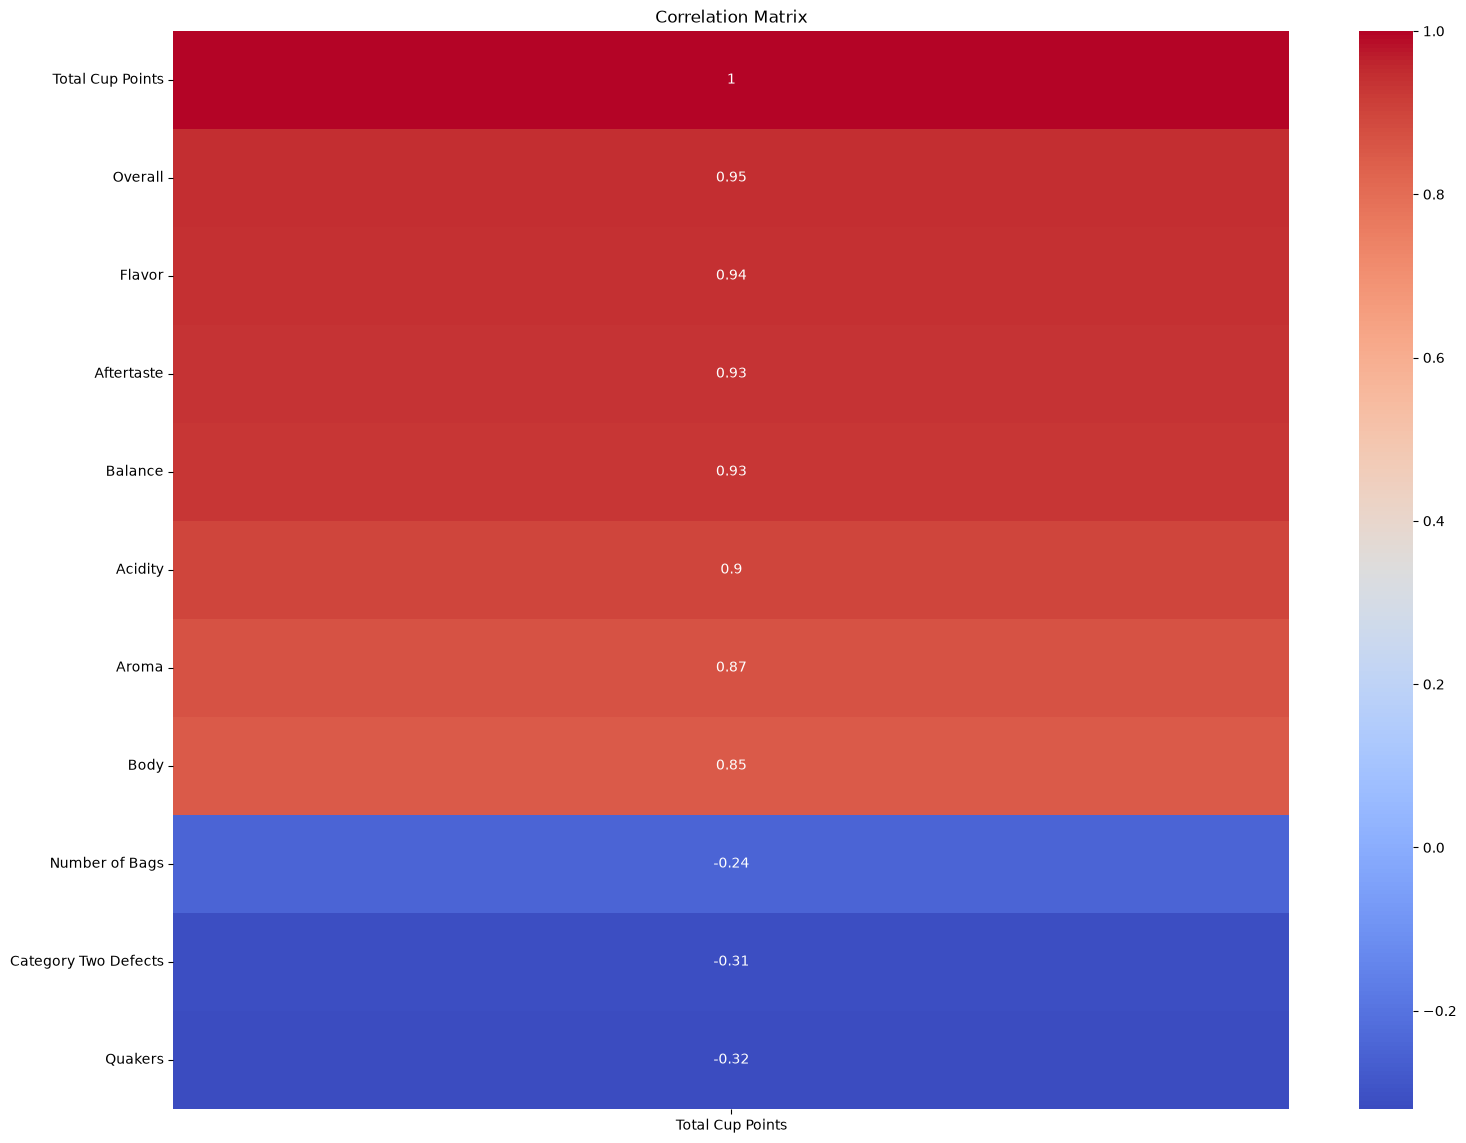

In [296]:
plt.figure(figsize=(18,14))
sns.heatmap(
    corr[["Total Cup Points"]].sort_values(
            by = "Total Cup Points",
            ascending=False
    ),
    annot=True,
    cmap="coolwarm"
    )
plt.title("Correlation Matrix")
plt.show()

#             Thank you for checking out this project!! :D